In [1]:
import pandas as pd 
import numpy as np
import random
import os 
import json
import torch
import pickle
import matplotlib.pyplot as plt
from sklearn.utils import shuffle 
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.utils.data import TensorDataset
from attrdict import AttrDict
from sklearn.preprocessing import minmax_scale
from transformers import AdamW, get_linear_schedule_with_warmup
from transformers import BertConfig, BertTokenizer, BertModel
from torchmetrics import R2Score

In [2]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="3"

In [3]:
default_path = os.getcwd()
data_path = os.path.join(default_path, '../data')
base_model = os.path.join(default_path, '../base-model')
model_path = os.path.join(default_path, '../models')
config_path = os.path.join(default_path, '../config')
log_path = os.path.join(default_path, '../log')
config_file = "bert-base.json"

In [4]:
criteria = 1

In [5]:
X_train = pd.read_csv(os.path.join(data_path, f'bws_a{criteria}_score_train.csv'))
X_dev = pd.read_csv(os.path.join(data_path, f'bws_a{criteria}_score_val.csv'))
X_test = pd.read_csv(os.path.join(data_path, f'bws_a{criteria}_score_test.csv'))

In [6]:
data = pd.read_csv(os.path.join(data_path, f'untagged_a{criteria}_pseudo.csv'))

In [7]:
data.columns = ['id', 'subreddit', 'author', 'text', 'type', 'time', 'parent_id', 'o_id', 'tok_len', 'criteria', 'group_a', 'group_b', 'group_c', 'pseudo']

In [8]:
data['label'] = 0

In [9]:
len(data)

90048

In [10]:
data.head(1)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,criteria,group_a,group_b,group_c,pseudo,label
0,al526,depression,unremedied,I have had all of these problems for as long a...,post,1.262551e+09,al526,al526,35,0,True,False,False,5,0


In [11]:
tokenizer = BertTokenizer.from_pretrained(os.path.join(base_model, 'bert-base'), model_max_length=128)
config = BertConfig.from_pretrained(os.path.join(base_model, 'bert-base', 'bert_config.json'))
model = BertModel.from_pretrained(os.path.join(base_model, 'bert-base'), config=config)

In [12]:
with open(os.path.join(config_path, 'training_config.json')) as f:
    training_config = AttrDict(json.load(f))

In [13]:
training_config.device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

In [14]:
training_config

AttrDict({'default_path': '../', 'data_path': 'data', 'log_path': 'log', 'model_path': 'model', 'config_path': 'config', 'seed': 42, 'train_batch_size': 8, 'device': device(type='cuda'), 'eval_batch_size': 8, 'num_epochs': 10, 'gradient_accumulation_steps': 1, 'warmup_proportion': 0, 'adam_epsilon': 1e-08, 'learning_rate': 5e-05, 'do_lower_case': False, 'no_cuda': False, 'max_steps': -1, 'logging_steps': 100})

In [15]:
training_config.learning_rate

5e-05

In [16]:
training_config.pad = 'max_length'
training_config.num_epochs = 5

In [17]:
training_config.model_path = model_path
training_config.log_path = log_path

In [18]:
class BertDataset(Dataset):
    def __init__(self, data_file):
        self.data = data_file
    
    def __len__(self):
        return len(self.data.label)
    
    def reset_index(self):
        self.data.reset_index(inplace=True, drop=True)
    
    def __getitem__(self, idx):
        '''
        return text, label
        '''
        self.reset_index()
        text = self.data.text[idx]
        label = self.data.label[idx]
        return text, label

In [19]:
class BertProcessor():
    def __init__(self, config, training_config, tokenizer, truncation=True):
        self.tokenizer = tokenizer 
        self.max_len = config.max_position_embeddings
        self.pad = training_config.pad
        self.batch_size = training_config.train_batch_size
        self.truncation = truncation
    
    def convert_data(self, data_file):
        context2 = None    # single sentence classification
        batch_encoding = self.tokenizer.batch_encode_plus(
            [(data_file[idx][0], context2) for idx in range(len(data_file))],   # text, 
            max_length = self.max_len,
            padding = self.pad,
            truncation = self.truncation
        )
        
        features = []
        for i in range(len(data_file)):
            inputs = {k: batch_encoding[k][i] for k in batch_encoding}
            try:
                inputs['label'] = data_file[i][1] 
            except:
                # print('input label 오류')
                inputs['label'] = 0 
            features.append(inputs)
        
        all_input_ids = torch.tensor([f['input_ids'] for f in features], dtype=torch.long)
        all_attention_mask = torch.tensor([f['attention_mask'] for f in features], dtype=torch.long)
        all_token_type_ids = torch.tensor([f['token_type_ids'] for f in features], dtype=torch.long)
        all_labels = torch.tensor([f['label'] for f in features], dtype=torch.long)

        dataset = TensorDataset(all_input_ids, all_attention_mask, all_token_type_ids, all_labels)
        return dataset
    
    def shuffle_data(self, dataset, data_type):
        if data_type == 'train':
            return RandomSampler(dataset)
        elif data_type == 'eval' or data_type == 'test':
            return SequentialSampler(dataset)
        
    def load_data(self, dataset, sampler):
        return DataLoader(dataset, sampler=sampler, batch_size=self.batch_size)

In [20]:
def RMSELoss(yhat,y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [21]:
class BertRegressor(nn.Module):
    def __init__(self, config, model):
        super(BertRegressor, self).__init__()
        self.model = model
        self.linear = nn.Linear(config.hidden_size, 128)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, 1)
    
    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        logits = outputs.last_hidden_state[:, 0, :]
        # print(f'logits: {len(logits)}, {len(logits[0])}')
        x = self.linear(logits)
        x = self.relu(x)
        score = self.out(x)
        # print(f'score: {score}')
        return score 

In [22]:
class BertTrainer():
    def __init__(self, config, training_config, model, train_dataloader, eval_dataloader):
        self.config = config
        self.training_config = training_config
        self.model = model
        self.train_dataloader = train_dataloader
        self.eval_dataloader = eval_dataloader
        
    def set_seed(self):
        random.seed(self.training_config.seed)
        np.random.seed(self.training_config.seed)
        torch.manual_seed(self.training_config.seed)
        if not self.training_config.no_cuda and torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.training_config.seed)
    
    def train(self):
        global_step = 0; nb_eval_steps = 0
        train_rmse = []; eval_rmse = []
        t_total = len(self.train_dataloader) // self.training_config.gradient_accumulation_steps * self.training_config.num_epochs

        optimizer = AdamW(self.model.parameters(), lr=self.training_config.learning_rate, eps=self.training_config.adam_epsilon)
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(t_total * self.training_config.warmup_proportion), \
                                                    num_training_steps=t_total)
        
        criterion = RMSELoss
        # criterion = nn.MSELoss()
        best_loss = 9999 
        
        self.model.zero_grad()
        for epoch in range(int(self.training_config.num_epochs)):
            train_loss = 0.0; eval_loss = 0.0 
            
            for step, batch in enumerate(self.train_dataloader):
                self.model.train()
                batch = tuple(t.to(self.training_config.device) for t in batch)
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    "token_type_ids": batch[2],
                }
                outputs = self.model(**inputs)
                # print(f'output: {type(outputs)}, {outputs.squeeze}')
                label = batch[3]
                # print(f'label: {label}')
                # print(f'output: {outputs}, {outputs.squeeze()}')
                loss = criterion(outputs.squeeze(), batch[3].type_as(outputs))
                loss.backward()
                
                train_loss += loss.item()
                # torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.training_config.max_grad_norm)
                optimizer.step()
                scheduler.step()
                
                self.model.zero_grad()
            
            print(f'epoch: {epoch + 1} done, train_loss: {train_loss / len(self.train_dataloader)}')
            train_rmse.append(train_loss / len(self.train_dataloader))

            for step2, batch2 in enumerate(self.eval_dataloader):
                self.model.eval()
                batch2 = tuple(t.to(self.training_config.device) for t in batch2)

                with torch.no_grad():
                    inputs = {
                        "input_ids": batch2[0],
                        "attention_mask": batch2[1],
                        "token_type_ids": batch2[2],
                    }
                    label2 = batch2[3]
                    outputs = self.model(**inputs)
                    print(f'eval output: {outputs.squeeze()}, eval label: {label2.type_as(outputs)}')
                    tmp_eval_loss = criterion(outputs.squeeze(), label2.type_as(outputs))
                    eval_loss += tmp_eval_loss.mean().item()
                    
                nb_eval_steps += 1

            eval_loss = eval_loss / nb_eval_steps
            eval_rmse.append(eval_loss)

        self.save_log(train_rmse, eval_rmse, epoch+1)
        self.save_model(os.path.join(self.training_config.default_path, self.training_config.model_path, f'bert-base_a{criteria}_e{training_config.num_epochs}.pt'))
        return train_rmse, eval_rmse

    def save_log(self, train_mse, eval_mse, epoch):
        with open(os.path.join(self.training_config.default_path, self.training_config.log_path, f'train_{epoch}_mse.pickle'), 'wb') as f:
            pickle.dump(train_mse, f, pickle.HIGHEST_PROTOCOL)  
        
        with open(os.path.join(self.training_config.default_path, self.training_config.log_path, f'eval_{epoch}_mse.pickle'), 'wb') as f:
            pickle.dump(eval_mse, f, pickle.HIGHEST_PROTOCOL)  
    
    def save_model(self, model_name):
        torch.save(self.model.state_dict(), model_name)

In [23]:
train_file = BertDataset(X_train)
val_file = BertDataset(X_dev)
test_file = BertDataset(X_test)

In [24]:
len(train_file), len(val_file)

(1152, 128)

In [25]:
config.max_position_embeddings = 128
config.max_position_embeddings

128

In [26]:
bert_processor = BertProcessor(config, training_config, tokenizer)

In [27]:
train_dataset = bert_processor.convert_data(train_file)
val_dataset = bert_processor.convert_data(val_file)
test_dataset = bert_processor.convert_data(test_file)

In [28]:
train_sampler = bert_processor.shuffle_data(train_dataset, 'train')
val_sampler = bert_processor.shuffle_data(val_dataset, 'eval')
test_sampler = bert_processor.shuffle_data(test_dataset, 'test')

In [29]:
train_dataloader = bert_processor.load_data(train_dataset, train_sampler)
val_dataloader = bert_processor.load_data(val_dataset, val_sampler)
test_dataloader = bert_processor.load_data(test_dataset, test_sampler)

In [30]:
len(train_dataloader), len(val_dataloader)

(144, 16)

In [31]:
model_reg = BertRegressor(config, model).to(training_config.device)  

In [32]:
bert_trainer = BertTrainer(config, training_config, model_reg, train_dataloader, val_dataloader)

In [33]:
train_mse, eval_mse = bert_trainer.train()

/home/pbl1/anaconda3/envs/aaai/lib/python3.8/site-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


epoch: 1 done, train_loss: 2.3148537621729903
eval output: tensor([1.0513, 6.8245, 5.5704, 2.2085, 6.7547, 2.7274, 6.5074, 6.6876],
       device='cuda:0'), eval label: tensor([3., 7., 5., 2., 5., 8., 7., 9.], device='cuda:0')
eval output: tensor([6.7310, 6.2215, 2.2158, 6.1169, 5.7143, 6.2333, 6.1452, 0.8233],
       device='cuda:0'), eval label: tensor([6., 8., 5., 5., 5., 5., 8., 3.], device='cuda:0')
eval output: tensor([6.5700, 4.8653, 5.8389, 4.8556, 1.9749, 1.8062, 2.8973, 3.7798],
       device='cuda:0'), eval label: tensor([8., 2., 5., 5., 2., 0., 5., 4.], device='cuda:0')
eval output: tensor([6.6962, 3.6025, 6.8925, 3.7555, 0.4970, 5.2603, 5.6052, 6.7851],
       device='cuda:0'), eval label: tensor([9., 4., 8., 1., 0., 6., 6., 8.], device='cuda:0')
eval output: tensor([1.5652, 6.3222, 4.5882, 6.4689, 6.8188, 6.8434, 6.8603, 6.4933],
       device='cuda:0'), eval label: tensor([1., 3., 5., 5., 8., 7., 7., 0.], device='cuda:0')
eval output: tensor([6.4805, 6.7601, 6.8847, 3.06

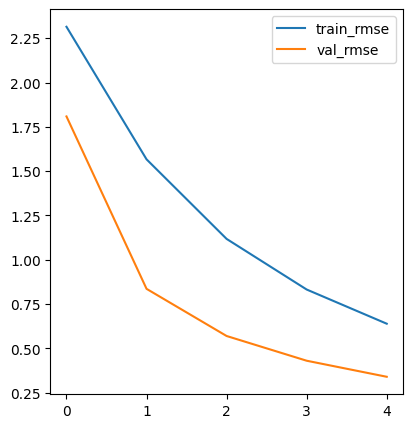

In [34]:
num_epochs = list(range(len(train_mse)))
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(list(range(len(train_mse))), train_mse, label='train_rmse')
plt.plot(list(range(len(eval_mse))), eval_mse, label='val_rmse')

plt.legend()
plt.show()

In [35]:
from sklearn.metrics import precision_score , recall_score , confusion_matrix, f1_score, classification_report

In [36]:
class BertRegTester():
    def __init__(self, training_config, model):
        self.training_config = training_config
        self.model = model

    def get_label(self, test_dataloader, test_type):
        '''
        test_type: 0  -> Test dataset 
        test_type: 1  -> Test sentence
        '''
        preds = []
        labels = []

        for batch in test_dataloader:
            self.model.eval()   # self 안 붙이면 이상한 Output (BaseModelOutputWithPoolingAndCrossAttentions) 출력 
            batch = tuple(t.to(self.training_config.device) for t in batch)   # args.device: cuda 
            with torch.no_grad():
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    "token_type_ids": batch[2],
                }
                outputs = self.model(**inputs)
                if test_type == 0:
                    try:
                        # print(f'len preds: {len(preds)}')
                        preds.extend(outputs.squeeze().detach().cpu().numpy())
                    except:
                        # print(outputs)
                        preds.extend(outputs[0].detach().cpu().numpy())
                elif test_type == 1:
                    preds.extend(outputs[0].detach().cpu().numpy())            
            label = batch[3].detach().cpu().numpy()
            labels.extend(label)
        return preds, labels 

In [37]:
bert_tester = BertRegTester(training_config, model_reg)

In [38]:
import time 

start = time.time()
y_pred, y_true = bert_tester.get_label(test_dataloader, 0)
print(f'소요 시간: {time.time() - start}')

소요 시간: 0.3164958953857422


In [39]:
y_pred[:3], y_true[:3]

([3.5333083, 5.845748, 2.605793], [1, 8, 4])

In [40]:
def RMSELoss(yhat,y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [41]:
criterion = RMSELoss

In [42]:
loss = criterion(torch.Tensor(y_pred), torch.Tensor((y_true)))
loss

tensor(1.5885)

In [43]:
r2score = R2Score()
r2score(torch.Tensor(y_pred), torch.Tensor(y_true))

tensor(0.6542)

In [44]:
conv = ['hey', 'I feel very depressed', 'I feed depressed', 'I feel sad', 'I cry everyday', 'I went to school', 'I want to die']
dep_test = pd.DataFrame(conv, columns=['text'])
dep_test['label'] = 9999

In [45]:
test_file = BertDataset(dep_test)
test_dataset = bert_processor.convert_data(test_file)
test_sampler = bert_processor.shuffle_data(test_dataset, 'test')
test_dataloader = bert_processor.load_data(test_dataset, test_sampler)

In [46]:
y_pred, y_true = bert_tester.get_label(test_dataloader, 0)

In [47]:
dep_test['label'] = [pred for pred in y_pred]
dep_test

,text,label
0,hey,2.721444
1,I feel very depressed,8.691945
2,I feed depressed,4.091382
3,I feel sad,4.741813
4,I cry everyday,8.067646
5,I went to school,3.461600
6,I want to die,8.024191


In [48]:
untagged_file = BertDataset(data)
untagged_dataset = bert_processor.convert_data(untagged_file)
untagged_sampler = bert_processor.shuffle_data(untagged_dataset, 'test')
untagged_dataloader = bert_processor.load_data(untagged_dataset, untagged_sampler)

In [49]:
y_pred, y_true = bert_tester.get_label(untagged_dataloader, 0)

In [50]:
def convert_score(score):
    if score < 0:
        score = 0
    elif score >= 11:
        score = 10
    return round(score, 1)

In [51]:
data['label'] = y_pred
data['label'] = data.label.apply(convert_score)
data.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,criteria,group_a,group_b,group_c,pseudo,label
0,al526,depression,unremedied,I have had all of these problems for as long a...,post,1.262551e+09,al526,al526,35,0,True,False,False,5,5.5
1,t3_7djh5r,depression,j0siahs74,Yes! I have been having crazy ass dreams some...,comment,1.510909e+09,t1_dpy9scj,dpy9zxp,22,0,True,False,False,6,5.0
2,al526,depression,unremedied,So am I depressed? I am honestly unsure mysel...,post,1.262551e+09,al526,al526,25,0,True,False,False,5,5.8


In [52]:
len(data)

90048

In [53]:
data = data[['id', 'subreddit', 'author', 'text', 'type', 'time', 'parent_id', 'o_id', 'tok_len', 'criteria', 'group_a', 'group_b', 'group_c', 'label']]
data.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,criteria,group_a,group_b,group_c,label
0,al526,depression,unremedied,I have had all of these problems for as long a...,post,1.262551e+09,al526,al526,35,0,True,False,False,5.5
1,t3_7djh5r,depression,j0siahs74,Yes! I have been having crazy ass dreams some...,comment,1.510909e+09,t1_dpy9scj,dpy9zxp,22,0,True,False,False,5.0
2,al526,depression,unremedied,So am I depressed? I am honestly unsure mysel...,post,1.262551e+09,al526,al526,25,0,True,False,False,5.8


In [54]:
data.to_csv(os.path.join(data_path, f'untagged_pseudo_a{criteria}.csv'), index=False)

In [55]:
data_train, data_test = train_test_split(data, test_size=0.2, random_state=42) #, stratify=a1.label)
data_train, data_dev = train_test_split(data_train, test_size=0.1, random_state=42) #, stratify=a1_train.label)

In [56]:
data_train.to_csv(os.path.join(data_path, f'untagged_pseudo_a{criteria}_train.csv'), index=False)
data_dev.to_csv(os.path.join(data_path, f'untagged_pseudo_a{criteria}_val.csv'), index=False)
data_test.to_csv(os.path.join(data_path, f'untagged_pseudo_a{criteria}_test.csv'), index=False)

In [57]:
data_train.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,criteria,group_a,group_b,group_c,label
54362,t3_cmcier,depression,[deleted],it makes me sad we can not be understood in th...,comment,1.565080e+09,t3_cmcier,ew3i615,12,0,True,False,False,4.3
7827,5a7k0a,depression,29022012,However since she became depressed our sex l...,post,1.477853e+09,5a7k0a,5a7k0a,39,0,True,False,False,2.8
72266,5zo29c,depression,TedBundysSon,Everytime I look at myself in the mirror I jus...,post,1.489632e+09,5zo29c,5zo29c,19,0,True,False,False,5.6


In [58]:
len(data_train)

64834